# INT8 PTQ Sufficiency & FPGA Feasibility Analysis

## 0. Executive Summary

Decision-Oriented Experiment Notebook

Model : MobileNetV2
Target HW : PYNQ, FPGA Systolic Array
Precision: INT8(Weight, Activation), psum 24bit

Objectives:
1. Determine whether PTQ is sufficient to build INT8 baseline
2. Verify feasibility of 24-bit psum accumulation
3. Decide whether QAT is REQUIRED or NOT

Final Outputs:
- PTQ sufficient / insufficient
- If insufficient: reason (HW vs model)
- Justification for QAT

## 1. Decision Criteria Definition (판단 기준 선언)

1. Decision Criteria

Accuracy Criterion:
ΔAcc = FP32 Acc - INT8 Acc
Acceptable if  ΔAcc <= 1.0%

Hardware Criterion:
- psum overflow rate should be ~0
- overflow must not correlate with misclassification

Decision Rules:
- If accuracy acceptable & no overflow -> PTQ sufficient
- If overflow dominates -> HW (bit-width) issue
- If accuracy poor without overflow -> QAT required

## 2. Environment & Reproducibility

In [1]:
# ------------------------------------------------------------
# 2. Environment & Reproducibility
# ------------------------------------------------------------
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 3. Dataset Preparation (Calibration / Validation 분리)

In [ ]:
# Calibration : ImageNet train 10k
# Validation : ImageNet val 5k

from torchvision import transforms
from datasets import load_dataset
from itertools import islice

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def preprocess(example):
    img = example["image"]
    if img.mode != "RGB":
        img = img.convert("RGB")
    example["image"] = transform(img)
    return example

ds = load_dataset(
    "ILSVRC/imagenet-1k",
    split="train",
    streaming=True
)

ds_calib = ds.shuffle(buffer_size=10000, seed=42)
ds_calib = ds_calib.map(preprocess)


ds_val = load_dataset(
    "ILSVRC/imagenet-1k",
    split="validation",
    streaming=True
)

ds_val = ds_val.map(preprocess)

In [ ]:
ds_calib_10k = list(islice(ds_calib, 10000))
ds_calib_1k = list(islice(ds_calib, 1000))

ds_val_5k = list(islice(ds_val, 5000))
ds_val_1k = list(islice(ds_val, 1000))
ds_val_100 = list(islice(ds_val, 100))

## 4. FP32 Baseline (Reference Line)

- 이 데이터셋 + 이 전처리 + 이 모델에서 정상적인 최대 성능이 얼마인가?

Note:
- This FP32 baseline is evaluated using the original pretrained
- MobileNetV2 without model fusion
- It serves as the reference performance for all subsequent
- INT8/PTQ/QAT experiments.

In [ ]:
# Evaluation
def evaluate(model, dataset, batch_size=32, total_samples=None):
    model.eval()
    correct = 0
    total = 0

    images = []
    labels = []

    with torch.no_grad():
        for sample in tqdm(dataset, total=total_samples, desc="Evaluation", ncols=100):
            images.append(sample["image"])
            labels.append(sample["label"])

            if len(images) == batch_size:
                inputs = torch.stack(images).to(EVAL_DEVICE)
                targets = torch.tensor(labels).to(EVAL_DEVICE)

                outputs = model(inputs)
                preds = outputs.argmax(dim=1)

                correct += (preds == targets).sum().item()
                total += targets.size(0)

                images.clear()
                labels.clear()

        # leftover
        if len(images) > 0:
            inputs = torch.stack(images).to(EVAL_DEVICE)
            targets = torch.tensor(labels).to(EVAL_DEVICE)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            correct += (preds == targets).sum().item()
            total += targets.size(0)

    return 100.0 * correct / total

In [ ]:
def evaluate_fp32(model, dataset):
    correct = 0
    total = 0

    with torch.no_grad():
        for sample in dataset:
            inputs = sample["image"].unsqueeze(0).to(DEVICE) # [1, 3, 224, 224]
            labels = sample["label"]

            outputs = model(inputs)
            pred = outputs.argmax(dim=1).item()

            correct += (pred == labels)
            total += 1

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
import torch
from torchvision import models
from torchvision.models import MobileNet_V2_Weights

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load original FP32 pretrained model
model_fp32 = models.mobilenet_v2(weights = MobileNet_V2_Weights.IMAGENET1K_V1)
model_fp32.eval()
model_fp32.to(DEVICE)


# 2. Evaluate FP32 baseline on 5k validation set
fp32_accuracy = evaluate(model_fp32, ds_val_5k)
print(f"FP32 Baseline Accuracy on 5k Validation Set: {fp32_accuracy:.2f}%")

Evaluation: 100%|███████████████████████████████████████████████| 5000/5000 [03:04<00:00, 27.12it/s]


FP32 Baseline Accuracy on 5k Validation Set: 72.62%


In [7]:
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Model device:", next(model_fp32.parameters()).device)

CUDA available: False
Current device: CPU
Device name: CPU
Model device: cpu


## 5. Quantization Strategy Overview (실험 설계 요약)

- The goal of this experiment is to determine whether a PTQ-based
INT8 model is sufficient for deploying MobileNetV2 on an FPGA
systolic array with a 24-bit partial-sum (psum) accumulator.

- Since accuracy degradation in INT8 inference can originate from multiple sources,
quantization is applied progressively to isolate the dominate cause

### Progressive Quantization Strategy

The quantization process is divided into three global steps:

**Step 1 - Weight only INT8**
- Weights are quantized to INT8
- Activations and accumulation remain in FP32
- Purpose: verfiy whether weight quantization alone causes significant accuracy degradation

**Step 2 - Weight + Activation INT8**
- Both weights and activations are quantized to INT8
- Accumulation remains in FP32
- Purpose : evaluate whether PTQ is sufficient for this model
- This step is the primary decision step for determining the necessity of QAT

**Step 3 - INT8 with 24-bit psum accumulation**
- Weights and activations are INT8
- Accumulation is constrained to 24-bit to reflect FPGA hardware
- Purpose : assess hardware feasibility and identify psum overflow

### Decision Policy

- If accuracy degradation is acceptable at Step 2, PTQ is considered sufficient and QAT is not required
- If significant accuracy degradation occurs at Step 2 without psum overflow, the limitations is attributed to PTQ, and QAT is justified
- If degradation occurs only at Step 3, the limitation is attributed to hardware accumulation width rather than quantization strategy

## 6. Step 1. Weight Only INT8 PTQ (Global Diagnosis)

Interpretation
- Step 1 isolates the impact of weight quantization
- Minimal accuracy degradation here indicates that weight only INT8 quantization is not the dominant source of error in subsequent INT8 inference

Note:
- Activation observers are disabled so that activation statistics are not collected and activations remain in FP32
- Actual INT8 conversion of weights is performed in convert()

In [14]:
import torch
from torchvision import models
from torchvision.models import MobileNet_V2_Weights
from torchvision.models.quantization import mobilenet_v2
from torch.ao.quantization.observer import PerChannelMinMaxObserver

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load original FP32 pretrained model
model_fp32 = models.mobilenet_v2(weights = MobileNet_V2_Weights.IMAGENET1K_V1)
model_fp32.eval()

# 2. Load Quantizable MobileNetV2 (structure only)
model_step1 = mobilenet_v2(quantize=False)
model_step1.eval()

# 3. Copy pretrained weights from FP32 model to quantizable model
model_step1.load_state_dict(model_fp32.state_dict())

# 4. Fuse Conv-BN-ReLU modules
model_step1.fuse_model()

# 5. Collect per-channel weight statistics (Conv only)
weight_observer = PerChannelMinMaxObserver(
    dtype=torch.qint8,
    qscheme=torch.per_channel_symmetric
)

# 6. Quantize -> Dequantize weights
with torch.no_grad():
    for m in model_step1.modules():
        if isinstance(m, torch.nn.Conv2d):
            
            # 1. Conv마다 observer 생성
            observer = PerChannelMinMaxObserver(
                dtype=torch.qint8,
                qscheme=torch.per_channel_symmetric
            )

            # 2. Weight 통계 수집
            observer(m.weight)

            scale, zero_point = observer.calculate_qparams()

            # 3. Quantize -> Dequantize
            q_w = torch.quantize_per_channel(
                m.weight,
                scale,
                zero_point,
                axis=0,
                dtype=torch.qint8
            )
            m.weight.copy_(q_w.dequantize())

In [ ]:
step1_acc = evaluate(model_step1, ds_val_5k)
print(f"Step 1 Accuracy (Weight INT8): {step1_acc:.2f}%")
print(f"Accuracy Drop from FP32: {fp32_accuracy - step1_acc:.2f}%")

Step 1 Accuracy (Weight INT8): 71.82%
Accuracy Drop from FP32: 0.58%


In [16]:
print(model_step1)

QuantizableMobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): ConvReLU2d(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
      (1): Identity()
      (2): Identity()
    )
    (1): QuantizableInvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): ConvReLU2d(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
            (1): ReLU()
          )
          (1): Identity()
          (2): Identity()
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1))
        (2): Identity()
      )
      (skip_add): FloatFunctional(
        (activation_post_process): Identity()
      )
    )
    (2): QuantizableInvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): ConvReLU2d(
            (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1))
            (1): ReLU()
          )
   

## 7. Step 2. Weight + Activation INT8 (Global Diagnosis)

In [ ]:
import torch
from torchvision import models
from torchvision.models import MobileNet_V2_Weights
from torchvision.models.quantization import mobilenet_v2
from torch.ao.quantization import get_default_qconfig, prepare, convert

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. 모델 준비

## FP32 pretrained
model_fp32 = models.mobilenet_v2(
    weights=MobileNet_V2_Weights.IMAGENET1K_V1
)
model_fp32.eval()

## Quantizable structure
model_quantizable = mobilenet_v2(quantize=False)
model_quantizable.eval()

## Copy weights
model_quantizable.load_state_dict(model_fp32.state_dict())

# 2. Fuse
model_quantizable.fuse_model()

# 3. qconfig 설정 (Weight + Activation INT8)
torch.backends.quantized.engine = "fbgemm"

model_quantizable.qconfig = get_default_qconfig("fbgemm")

# 4. Prepare the model for quantization (Observer 삽입)
model_prepared = prepare(model_quantizable, inplace=False)

# 5. Calibrate with 10k training samples (Activation Scale & Zero-Point 수집)
model_prepared.eval()

with torch.no_grad():
    for sample in ds_calib_10k:
        inputs = sample["image"].unsqueeze(0).to(DEVICE) # [1, 3, 224, 224]
        model_prepared(inputs)

# 6. Convert to INT8 (INT8 모델 생성)
model_ptq = convert(model_prepared, inplace=False)
model_ptq.eval()

/Users/Kpiano/miniconda3/envs/qat/lib/python3.10/site-packages/torch/ao/quantization/observer.py:220: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(
/Users/Kpiano/miniconda3/envs/qat/lib/python3.10/site-packages/torch/ao/quantization/observer.py:1263: UserWarning: must run observer before calling calculate_qparams.                                    Returning default scale and zero point 
  warnings.warn(


QuantizableMobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): QuantizedConvReLU2d(3, 32, kernel_size=(3, 3), stride=(2, 2), scale=0.022486776113510132, zero_point=0, padding=(1, 1))
      (1): Identity()
      (2): Identity()
    )
    (1): QuantizableInvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): QuantizedConvReLU2d(32, 32, kernel_size=(3, 3), stride=(1, 1), scale=0.08765512704849243, zero_point=0, padding=(1, 1), groups=32)
          (1): Identity()
          (2): Identity()
        )
        (1): QuantizedConv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), scale=0.09665374457836151, zero_point=65)
        (2): Identity()
      )
      (skip_add): QFunctional(
        scale=1.0, zero_point=0
        (activation_post_process): Identity()
      )
    )
    (2): QuantizableInvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): QuantizedConvReLU2d(16, 96, kernel_size=(1, 1), 

In [ ]:
# Validation (ImageNet val 5k)
step2_acc = evaluate(model_ptq, ds_val_5k)
print(f"Step 2 Accuracy (Weight + Activation INT8): {step2_acc:.2f}%")
print(f"Accuracy Drop from FP32: {fp32_accuracy - step2_acc:.2f}%")

Step 2 Accuracy (Weight + Activation INT8): 67.46%
Accuracy Drop from FP32: 4.94%


Accuracy Drop : 4.94 % 
- PTQ 전체 적용은 무리

## 8. Step 3. Block-Level Analysis

어느 Block까지는 괜찮고, 어느 block부터 accuracy가 급격히 무너지는가?
이를 통해
- QAT를 전체에 할지
- 일부 block만 QAT / FP32 유지할지
- FPGA에서 특정 block만 bit-width 완화할지
결정 가능

Step A
- Prefix block PTQ로 문제 block 2~4개 식별

Step B
- 그 Block들만
    - Activation scale
    - psum range
    - skip-add mismatch 확인

Step C
- 이 Block들은 QAT 필요
- 나머지는 PTQ로 충분

- Prefix Block PTQ 실험
- 앞에서부터 block을 하나씩 INT8로 바꿔가며 accuracy 측정
- 나머지는 FP32 유지

In [59]:
# 0. 준비
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import MobileNet_V2_Weights
from torchvision.models.quantization import mobilenet_v2
from torch.ao.quantization import get_default_qat_qconfig, prepare, convert
from torch.ao.quantization import disable_observer, enable_fake_quant
from torch.ao.quantization import get_default_qconfig_mapping
from torch.ao.quantization import QConfigMapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx, prepare_qat_fx
from torch.ao.quantization.fake_quantize import FakeQuantize
from tqdm.auto import tqdm
import torch.fx as fx
import re

CALIB_DEVICE = "cpu"
EVAL_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.quantized.engine = "fbgemm"

In [77]:
print(CALIB_DEVICE)
print(EVAL_DEVICE)

cpu
cpu


In [78]:
# (1) FX trace
# FP32 pretrained 모델 준비
model_fp32_ref = models.mobilenet_v2(
    weights = MobileNet_V2_Weights.IMAGENET1K_V1
).eval()

# 1. Quantizable 구조 + weight 복사
model_fp32_fused = mobilenet_v2(quantize=False).eval()
model_fp32_fused.load_state_dict(model_fp32_ref.state_dict())
model_fp32_fused.fuse_model()
model_fp32_fused.eval()

# 2. Prepare FX
qconfig = get_default_qat_qconfig("fbgemm")
qconfig_mapping = QConfigMapping().set_global(qconfig)

model_prepared = prepare_qat_fx(
    model_fp32_fused,
    qconfig_mapping,
    example_inputs=(torch.randn(1, 3, 224, 224).to(CALIB_DEVICE),)
).eval()

In [79]:
gm = model_prepared

In [80]:
for i, node in enumerate(gm.graph.nodes):
    print(i, node.op, node.target)

0 placeholder x
1 call_module activation_post_process_0
2 call_module features.0.0
3 call_module activation_post_process_1
4 call_module features.0.1
5 call_module activation_post_process_2
6 call_module features.0.2
7 call_module activation_post_process_3
8 call_module features.1.conv.0.0
9 call_module activation_post_process_4
10 call_module features.1.conv.0.1
11 call_module activation_post_process_5
12 call_module features.1.conv.0.2
13 call_module activation_post_process_6
14 call_module features.1.conv.1
15 call_module activation_post_process_7
16 call_module features.1.conv.2
17 call_module activation_post_process_8
18 call_module features.2.conv.0.0
19 call_module activation_post_process_9
20 call_module features.2.conv.0.1
21 call_module activation_post_process_10
22 call_module features.2.conv.0.2
23 call_module activation_post_process_11
24 call_module features.2.conv.1.0
25 call_module activation_post_process_12
26 call_module features.2.conv.1.1
27 call_module activation_p

In [81]:
def get_prefix_feature_blocks(prefix_block_k):
    """
    prefix_block_k = 0  → empty set
    prefix_block_k = 1  → {"features.0"}
    prefix_block_k = 2  → {"features.0", "features.1"}
    ...
    """
    return {f"features.{i}" for i in range(prefix_block_k)}

In [82]:
def set_fakequant_by_feature_prefix(model, prefix_block_k):
    for name, module in model.named_modules():
        if isinstance(module, FakeQuantize) and name.endswith("weight_fake_quant"):
            parent = name.rsplit('.', 1)[0]

            # features.N 또는 features.N.xxx 만 매칭
            m = re.match(r"features\.(\d+)(\.|$)", parent)
            if m is None:
                module.disable_fake_quant()
                continue

            block_idx = int(m.group(1))
            if block_idx < prefix_block_k:
                module.enable_fake_quant()
            else:
                module.disable_fake_quant()

In [83]:
def debug_enabled_fakequant(model):
    enabled = []
    for name, module in model.named_modules():
        if isinstance(module, FakeQuantize) and module.fake_quant_enabled and name.endswith("weight_fake_quant"):
            enabled.append(name)
    print(f"{len(enabled)} FakeQuant modules are enabled.")

In [84]:
def set_activation_fakequant_by_feature_prefix(gm, prefix_block_k):
    modules = dict(gm.named_modules())

    for node in gm.graph.nodes:
        if node.op != "call_module":
            continue

        if not node.target.startswith("activation_post_process"):
            continue


        fq = modules.get(node.target, None)
        if fq is None:
            continue

        # 이 activation의 입력 node
        prev = node.args[0]
        if not isinstance(prev, fx.Node):
            fq.disable_fake_quant()
            continue

        # prev가 어떤 module에서 나왔는지
        if prev.op != "call_module":
            fq.disable_fake_quant()
            continue

        src = prev.target   # 예: "features.3.conv.2"

        m = re.match(r"features\.(\d+)(\.|$)", src)
        if m is None:
            fq.disable_fake_quant()
            continue

        block_idx = int(m.group(1))
        if block_idx < prefix_block_k:
            fq.enable_fake_quant()
        else:
            fq.disable_fake_quant()


In [85]:
def debug_enabled_activation_fakequant(gm):
    modules = dict(gm.named_modules())
    enabled = []

    for node in gm.graph.nodes:
        if node.op != "call_module":
            continue
        if not node.target.startswith("activation_post_process"):
            continue

        fq = modules.get(node.target, None)
        if fq is None:
            continue
        
        if not fq.fake_quant_enabled:
            continue

        # activation의 source 추적
        prev = node.args[0]
        if not isinstance(prev, fx.Node):
            enabled.append((node.target, "unknown"))
            continue

        if prev.op != "call_module":
            enabled.append((node.target, prev.op))
            continue

        enabled.append((node.target, prev.target))

    print(f"{len(enabled)} Activation FakeQuant modules are enabled.")
    for name, src in enabled:
        print(f"  {name}  <-- from {src}")

In [ ]:
def build_prefix_ptq_model(PREFIX_BLOCK_K):
    torch.backends.quantized.engine = "fbgemm"

    # FP32 baseline : model_fp32_ref
    # Quantization base : model_fp32_fused
    # Prefix-quantized : model_int8_prefix
    # Hyrid model : model_hybrid_prefix_ptq

    # 0. FP32 pretrained
    model_fp32_ref = models.mobilenet_v2(
        weights = MobileNet_V2_Weights.IMAGENET1K_V1
    ).eval().to(CALIB_DEVICE)

    # 1. Quantizable model + weight copy
    model_fp32_fused = mobilenet_v2(quantize=False).eval().to(CALIB_DEVICE)
    model_fp32_fused.load_state_dict(model_fp32_ref.state_dict())
    model_fp32_fused.fuse_model()

    # 2. Prepare FX
    qconfig = get_default_qat_qconfig("fbgemm")
    qconfig_mapping = QConfigMapping().set_global(qconfig)

    model_prepared = prepare_qat_fx(
        model_fp32_fused,
        qconfig_mapping,
        example_inputs=(torch.randn(1, 3, 224, 224).to(CALIB_DEVICE),)
    ).eval()

    # for name, module in model_prepared.named_modules():
    #     print(name, type(module))
        # if "weight_fake_quant" in name:
        #     print(name, type(module))

    # 3. Calibration with 10k training samples
    with torch.no_grad():
        for sample in tqdm(ds_train_1k, total=1000, desc="PTQ_Calibration"):
            inputs = sample["image"].unsqueeze(0).to(CALIB_DEVICE) # [1, 3, 224, 224]
            model_prepared(inputs)

    # 4. Block-prefix FakeQuant 제어
    set_fakequant_by_feature_prefix(model_prepared, PREFIX_BLOCK_K)

    # 5. Activation FakeQuant prefix 제어 (FX 기반)
    set_activation_fakequant_by_feature_prefix(model_prepared, PREFIX_BLOCK_K)

    # 5. Debug
    # print("=== Weight FakeQuant ===")
    # debug_enabled_fakequant(model_prepared)

    # print("=== Activation FakeQuant ===")
    # debug_enabled_activation_fakequant(model_prepared)
    
    return model_prepared

In [88]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="torch.ao.quantization.observer"
)

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="torch.ao.quantization"
)

In [89]:
# 1. PTQ calibration (CPU)
model = build_prefix_ptq_model(PREFIX_BLOCK_K=0)

# 2. Evaluation (GPU)
model = model.to(EVAL_DEVICE)
acc = evaluate(model, ds_val_1k, batch_size=32, total_samples=1000)

print(f"Prefix K={0}: Accuracy = {acc:.2f}%, Drop = {fp32_accuracy - acc:.2f}%")

PTQ_Calibration: 100%|██████████| 1000/1000 [01:58<00:00,  8.47it/s]


=== Weight FakeQuant ===
0 FakeQuant modules are enabled.
=== Activation FakeQuant ===
0 Activation FakeQuant modules are enabled.


Evaluation: 100%|███████████████████████████████████████████████| 1000/1000 [01:03<00:00, 15.86it/s]


Prefix K=0: Accuracy = 72.40%, Drop = 0.22%


In [72]:
model = build_prefix_ptq_model(PREFIX_BLOCK_K=2)
acc = evaluate(model, ds_val_1k)
print(f"Prefix K={2}: Accuracy = {acc:.2f}%, Drop = {fp32_accuracy - acc:.2f}%")

PTQ_Calibration: 100%|██████████| 1000/1000 [02:11<00:00,  7.61it/s]


=== Weight FakeQuant ===
3 FakeQuant modules are enabled.
=== Activation FakeQuant ===
3 Activation FakeQuant modules are enabled.
  activation_post_process_1  <-- from features.0.0
  activation_post_process_4  <-- from features.1.conv.0.0
  activation_post_process_7  <-- from features.1.conv.1


Evaluation: 100%|███████████████████████████████████████████████| 1000/1000 [00:55<00:00, 18.01it/s]


Prefix K=2: Accuracy = 71.90%, Drop = 0.72%


In [90]:
model = build_prefix_ptq_model(PREFIX_BLOCK_K=19)
acc = evaluate(model, ds_val_1k)
print(f"Prefix K={19}: Accuracy = {acc:.2f}%, Drop = {fp32_accuracy - acc:.2f}%")

PTQ_Calibration: 100%|██████████| 1000/1000 [02:07<00:00,  7.82it/s]


=== Weight FakeQuant ===
52 FakeQuant modules are enabled.
=== Activation FakeQuant ===
52 Activation FakeQuant modules are enabled.
  activation_post_process_1  <-- from features.0.0
  activation_post_process_4  <-- from features.1.conv.0.0
  activation_post_process_7  <-- from features.1.conv.1
  activation_post_process_9  <-- from features.2.conv.0.0
  activation_post_process_12  <-- from features.2.conv.1.0
  activation_post_process_15  <-- from features.2.conv.2
  activation_post_process_17  <-- from features.3.conv.0.0
  activation_post_process_20  <-- from features.3.conv.1.0
  activation_post_process_23  <-- from features.3.conv.2
  activation_post_process_26  <-- from features.4.conv.0.0
  activation_post_process_29  <-- from features.4.conv.1.0
  activation_post_process_32  <-- from features.4.conv.2
  activation_post_process_34  <-- from features.5.conv.0.0
  activation_post_process_37  <-- from features.5.conv.1.0
  activation_post_process_40  <-- from features.5.conv.2
  a

Evaluation: 100%|███████████████████████████████████████████████| 1000/1000 [01:10<00:00, 14.28it/s]


Prefix K=19: Accuracy = 71.50%, Drop = 1.12%


In [92]:
results = {}

for k in range(0, 20):
    model = build_prefix_ptq_model(PREFIX_BLOCK_K=k)
    acc = evaluate(model, ds_val_1k)
    results[k] = acc
    print(f"Prefix K={k}: Accuracy = {acc:.2f}%, Drop = {fp32_accuracy - acc:.2f}%")

PTQ_Calibration: 100%|██████████| 1000/1000 [01:42<00:00,  9.77it/s]


=== Weight FakeQuant ===
0 FakeQuant modules are enabled.
=== Activation FakeQuant ===
0 Activation FakeQuant modules are enabled.


Evaluation: 100%|███████████████████████████████████████████████| 1000/1000 [00:58<00:00, 17.02it/s]


Prefix K=0: Accuracy = 72.40%, Drop = 0.22%


PTQ_Calibration: 100%|██████████| 1000/1000 [01:44<00:00,  9.57it/s]


...

Prefix K=18: Accuracy = 71.60%, Drop = 1.02%


PTQ_Calibration: 100%|██████████| 1000/1000 [02:43<00:00,  6.10it/s]


=== Weight FakeQuant ===
52 FakeQuant modules are enabled.
=== Activation FakeQuant ===
52 Activation FakeQuant modules are enabled.
  activation_post_process_1  <-- from features.0.0
  activation_post_process_4  <-- from features.1.conv.0.0
  activation_post_process_7  <-- from features.1.conv.1
  activation_post_process_9  <-- from features.2.conv.0.0
  activation_post_process_12  <-- from features.2.conv.1.0
  activation_post_process_15  <-- from features.2.conv.2
  activation_post_process_17  <-- from features.3.conv.0.0
  activation_post_process_20  <-- from features.3.conv.1.0
  activation_post_process_23  <-- from features.3.conv.2
  activation_post_process_26  <-- from features.4.conv.0.0
  activation_post_process_29  <-- from features.4.conv.1.0
  activation_post_process_32  <-- from features.4.conv.2
  activation_post_process_34  <-- from features.5.conv.0.0
  activation_post_process_37  <-- from features.5.conv.1.0
  activation_post_process_40  <-- from features.5.conv.2
  a

Evaluation: 100%|███████████████████████████████████████████████| 1000/1000 [01:42<00:00,  9.77it/s]


Prefix K=19: Accuracy = 71.50%, Drop = 1.12%


In [93]:
results_5k = {}

for k in range(0, 20):
    model = build_prefix_ptq_model(PREFIX_BLOCK_K=k)
    acc = evaluate(model, ds_val_5k)
    results_5k[k] = acc
    print(f"Prefix K={k}: Accuracy = {acc:.2f}%, Drop = {fp32_accuracy - acc:.2f}%")

PTQ_Calibration: 100%|██████████| 1000/1000 [02:50<00:00,  5.87it/s]


=== Weight FakeQuant ===
0 FakeQuant modules are enabled.
=== Activation FakeQuant ===
0 Activation FakeQuant modules are enabled.


Evaluation: 100%|███████████████████████████████████████████████| 5000/5000 [07:57<00:00, 10.48it/s]


Prefix K=0: Accuracy = 72.66%, Drop = -0.04%


PTQ_Calibration: 100%|██████████| 1000/1000 [02:45<00:00,  6.06it/s]


...

Prefix K=18: Accuracy = 70.76%, Drop = 1.86%


PTQ_Calibration: 100%|██████████| 1000/1000 [02:07<00:00,  7.83it/s]


=== Weight FakeQuant ===
52 FakeQuant modules are enabled.
=== Activation FakeQuant ===
52 Activation FakeQuant modules are enabled.
  activation_post_process_1  <-- from features.0.0
  activation_post_process_4  <-- from features.1.conv.0.0
  activation_post_process_7  <-- from features.1.conv.1
  activation_post_process_9  <-- from features.2.conv.0.0
  activation_post_process_12  <-- from features.2.conv.1.0
  activation_post_process_15  <-- from features.2.conv.2
  activation_post_process_17  <-- from features.3.conv.0.0
  activation_post_process_20  <-- from features.3.conv.1.0
  activation_post_process_23  <-- from features.3.conv.2
  activation_post_process_26  <-- from features.4.conv.0.0
  activation_post_process_29  <-- from features.4.conv.1.0
  activation_post_process_32  <-- from features.4.conv.2
  activation_post_process_34  <-- from features.5.conv.0.0
  activation_post_process_37  <-- from features.5.conv.1.0
  activation_post_process_40  <-- from features.5.conv.2
  a

Evaluation: 100%|███████████████████████████████████████████████| 5000/5000 [05:51<00:00, 14.21it/s]


Prefix K=19: Accuracy = 70.76%, Drop = 1.86%


In [94]:
print(results)

{0: 72.4, 1: 71.8, 2: 71.9, 3: 72.0, 4: 72.3, 5: 72.5, 6: 72.3, 7: 72.1, 8: 71.8, 9: 71.9, 10: 71.8, 11: 71.5, 12: 71.8, 13: 71.6, 14: 71.4, 15: 71.5, 16: 71.5, 17: 71.5, 18: 71.6, 19: 71.5}


In [ ]:
print(results_5k)

{0: 72.66, 1: 72.32, 2: 71.74, 3: 71.06, 4: 71.12, 5: 71.22, 6: 71.26, 7: 71.24, 8: 71.06, 9: 71.04, 10: 71.06, 11: 70.84, 12: 70.8, 13: 70.74, 14: 70.82, 15: 70.88, 16: 70.74, 17: 70.96, 18: 70.76, 19: 70.76}


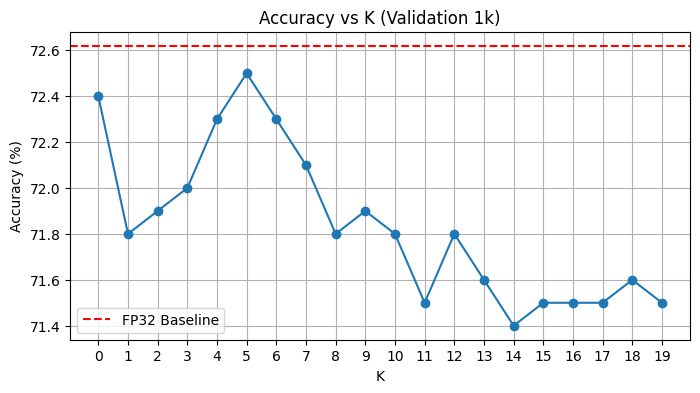

In [108]:
import matplotlib.pyplot as plt

x = list(results.keys())
y = list(results.values())

plt.figure(figsize=(8, 4))
plt.plot(x, y, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs K (Validation 1k)")
plt.axhline(72.62, color='r', linestyle='--', label='FP32 Baseline')

plt.xticks(x)

plt.legend()
plt.grid(True)
plt.show()

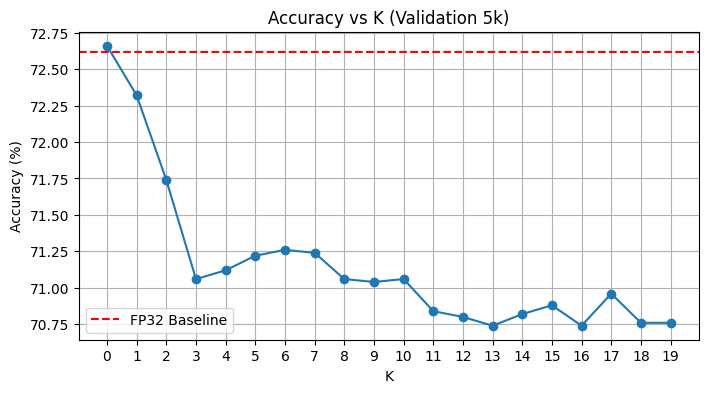

In [107]:
import matplotlib.pyplot as plt

x = list(results_5k.keys())
y = list(results_5k.values())

plt.figure(figsize=(8, 4))
plt.plot(x, y, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs K (Validation 5k)")
plt.axhline(72.62, color='r', linestyle='--', label='FP32 Baseline')

plt.xticks(x)

plt.legend()
plt.grid(True)
plt.show()